# Model Sanity check

In [1]:
import sys
import os

os.chdir("..")

In [2]:
from network import SimpleGridDetector
from dataset import LabeledDetectionDataset

In [4]:
from pathlib import Path
from training import explore_dataset

dataset_path = Path("../data_det_public/data_det_public")
df = explore_dataset(dataset_path)
dataset = LabeledDetectionDataset(df)
model = SimpleGridDetector(grid_size=10)

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch

def show_sample(sample: tuple[torch.Tensor, dict, torch.Tensor]) -> None:
    img, metadata, bboxes = sample
    img = img.permute(1, 2, 0)

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    for box in bboxes:
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()

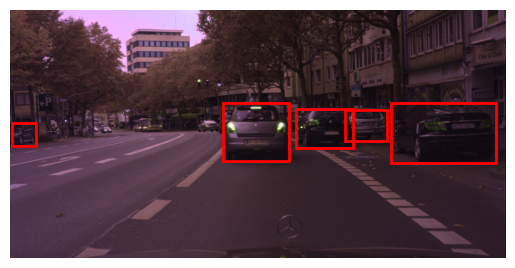

In [13]:
sample = dataset[8]

show_sample(sample)

In [14]:
pred = model(sample[0]) # can I do normalization ?

RuntimeError: Input type (unsigned char) and bias type (float) should be the same